#2 User requests a refund.

In [8]:
from langgraph.graph import StateGraph, END
from typing import TypedDict

from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.3-70b-versatile")

In [ ]:
🏢 Business Problem

User requests a refund.

If refund amount < ₹5,000 → auto approve.

If refund amount ≥ ₹5,000 → send to human manager for approval.

After human decision → finalize response.

This is classic Human-in-the-Loop conditional workflow.


User Query
    ↓
Refund Analysis Node
    ↓
Amount Check Router
    ↓
 ┌───────────────┬───────────────┐
 │               │
Auto Approve   Human Review Node
                     ↓
                Final Decision

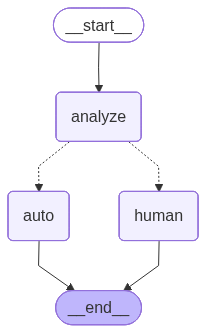

In [16]:
from langgraph.graph import StateGraph, END
from typing import TypedDict
import re

# ✅ Define State (make fields optional)
class RefundState(TypedDict, total=False):
    user_query: str
    amount: int
    approved: bool
    human_decision: bool
    response: str


# ✅ Extract amount from user query
def analyze_refund(state: RefundState):
    query = state["user_query"]

    match = re.search(r"\d+", query)

    if match:
        amount = int(match.group())
    else:
        amount = 0

    return {"amount": amount}


# ✅ Routing logic
def refund_router(state: RefundState):
    if state["amount"] < 5000:
        return "auto"
    else:
        return "human"


# ✅ Auto approve
def auto_approve(state: RefundState):
    return {
        "approved": True,
        "response": f"Your refund of ₹{state['amount']} has been approved automatically."
    }


# ✅ Human review
def human_review(state: RefundState):
    print("Waiting for human approval...")
    human_input = input("Approve refund? (yes/no): ")
    decision = human_input.lower().strip() == "yes"

    return {
        "human_decision": decision,
        "approved": decision,
        "response": f"Your refund of ₹{state['amount']} has been "
                    f"{'approved' if decision else 'rejected'} by our manager."
    }


# ✅ Build Graph
builder = StateGraph(RefundState)

builder.add_node("analyze", analyze_refund)
builder.add_node("auto", auto_approve)
builder.add_node("human", human_review)

builder.set_entry_point("analyze")

builder.add_conditional_edges(
    "analyze",
    refund_router,
    {
        "auto": "auto",
        "human": "human"
    }
)

# ✅ Correct edges
builder.add_edge("auto", END)
builder.add_edge("human", END)

graph = builder.compile()
graph 



In [18]:
result = graph.invoke({"user_query": "I want refund of 7000"})
print(result["response"])

Waiting for human approval...
Your refund of ₹7000 has been rejected by our manager.


In [17]:
# ✅ Run example
result = graph.invoke({
    "user_query": "I want refund of 1200"
})

print(result["response"])

Your refund of ₹1200 has been approved automatically.
